## **Redes Bayesianas**

Uma **Rede Bayesiana** é um modelo probabilístico definido por um par $(\mathcal{G}, \Theta)$, onde:

* **$\mathcal{G}$**: um **Grafo Acíclico Direcionado (DAG)**
* **$\Theta$**: conjunto de parâmetros das distribuições condicionais

Cada nó $X_i$ representa uma variável aleatória, e cada aresta representa uma dependência condicional direta.

Seja $X = (X_1, X_2, \dots, X_n)$. A distribuição conjunta fatoriza é dada por:

$$
P(X_1, X_2, \dots, X_n) = \prod_{i=1}^{n} P(X_i \mid \mathrm{Pa}(X_i))
$$

onde $\mathrm{Pa}(X_i)$ é o conjunto de pais de $X_i$ no grafo.

Esse modelo deseja superar Naive Bayes ao passo que neste último, assumimos — de forma ingênua — a independência condicional total:

$$
P(X_1, X_2, \dots, X_n \mid Y) = \prod_{i=1}^{n} P(X_i \mid Y)
$$

ou seja, $X_i \perp X_j \mid Y$ para todo $i \neq j$.

**Redes Bayesianas** generalizam essa hipótese permitindo dependências adicionais entre variáveis:

$$
P(Y, X_1, \dots, X_n) := P(Y) \prod_{i=1}^{n} P(X_i \mid \mathrm{Pa}(X_i))
$$

### **Fundamentação Probabilística**

Seja $X = (X_1, \dots, X_n)$ e uma variável de classe $Y$.

Pela regra da cadeia das  probabilidades:

$$
P(Y, X_1, \dots, X_n) = P(Y) \prod_{i=1}^{n} P(X_i \mid Y, X_1, \dots, X_{i-1})
$$

Em Redes Bayesianas, essa fatoração é simplificada usando o grafo:

$$
P(Y, X_1, \dots, X_n) := P(Y) \prod_{i=1}^{n} P(X_i \mid \mathrm{Pa}(X_i))
$$

onde $\mathrm{Pa}(X_i)$ depende da estrutura $\mathcal{G}$.

### **Aprendizado em Redes Bayesianas**

O aprendizado envolve duas etapas principais:

#### **Aprendizado da Estrutura**

Determinar o DAG que melhor representa as dependências entre as variáveis:

$$
\mathcal{G}^* = \arg\max_{\mathcal{G}} \ \text{Score}(\mathcal{G} \mid \mathcal{D})
$$

onde $\mathcal{D}$ é o conjunto de dados.

Funções de score comuns:

* Log-verossimilhança
* BIC (Bayesian Information Criterion)
* MDL (Minimum Description Length)

#### **Aprendizado dos Parâmetros**

Dada uma estrutura $\mathcal{G}$, o objetivo é estimar as distribuições de probabilidade condicionais associadas a cada nó:

$$
P(X_i \mid \mathrm{Pa}(X_i))
$$

Esses parâmetros podem ser estimados por **Máxima Verossimilhança (MLE)**:

$$
\hat{P}(x_i \mid \pi_i) = \frac{N(x_i, \pi_i)}{N(\pi_i)}
$$

onde:
* $N(x_i, \pi_i)$ é a contagem conjunta
* $N(\pi_i)$ é a contagem dos pais

Note que essa abordagem é para variáveis **discretas**.

### **Classificadores Bayesianos com $k$ dependências ($k$-DB)**

Cada variável $X_i$ pode depender:

* Da classe $Y$
* De no máximo $k$ outras variáveis

Logo:

$$
P(X_i \mid Y, \pi_i)
$$

com:

$$
\pi_i \subseteq \{X_1, \dots, X_n\}, \quad |\pi_i| \leq k
$$

onde $\pi_i = \mathrm{Pa}(X_i)$ representa o conjunto de pais de $X_i$ no grafo.

## **Implementação de Redes Bayesianas para problema de Classificação**

Vamos utilizar **Redes Bayesianas** para tarefa de **classificação**  no dataset [**Car Evaluation**](https://archive.ics.uci.edu/dataset/19/car+evaluation).

### **Pré-Processamento dos Dados**

In [13]:
!pip install ucimlrepo

#### **Dataset**

In [14]:
from ucimlrepo import fetch_ucirepo

car_evaluation = fetch_ucirepo(id=19)

X = car_evaluation.data.features
y = car_evaluation.data.targets

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (1728, 6)
Shape de y: (1728, 1)


In [15]:
df = X.copy()
df['class'] = y

df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [16]:
df["class"].value_counts()

,count
class,
unacc,1210
acc,384
good,69
vgood,65


#### **Divisão do dataset em dados de treino e validação**

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (1382, 6)
Teste: (346, 6)


### **Redes Bayesianas para Classificação**

In [18]:
!pip install pgmpy

#### **Construção do DAG $\mathcal{G}$**

In [19]:
from pgmpy.estimators import HillClimbSearch, BIC

df_train = X_train.copy()
df_train['class'] = y_train.values.squeeze()

df_train = df_train.astype(str)

scoring_method = BIC(data=df_train)
hc = HillClimbSearch(data=df_train)

best_model = hc.estimate(
    scoring_method=scoring_method,
    max_indegree=2,
    max_iter=int(1e4)
)

print("Arestas encontradas pelo Hill Climbing:")
print(best_model.edges())

  0%|          | 0/10000 [00:00<?, ?it/s]

Arestas encontradas pelo Hill Climbing:
[('buying', 'class'), ('maint', 'class'), ('class', 'safety'), ('class', 'persons'), ('class', 'lug_boot')]


Note quem nem todas as features obtiveram ligação no DAG.

#### **Estimação dos parâmetros $\Theta$**

In [20]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator

bn_model = DiscreteBayesianNetwork(best_model.edges())

bn_model.fit(
    data=df_train,
    estimator=MaximumLikelihoodEstimator
)

print("Parâmetros estimados com sucesso!")
print(f"Número de nós: {len(bn_model.nodes())}")
print(f"Número de arestas: {len(bn_model.edges())}")

Parâmetros estimados com sucesso!
Número de nós: 6
Número de arestas: 5


### **Realizando uma Predição**

In [21]:
from pgmpy.inference import VariableElimination

inference = VariableElimination(bn_model)

query = inference.query(variables=['class'], evidence={
    'buying': 'vhigh',
    'persons': '2',
    'lug_boot': 'small',
    'safety': 'high'
})

print(query)

+--------------+--------------+
| class        |   phi(class) |
+==============+==============+
| class(acc)   |       0.0000 |
+--------------+--------------+
| class(good)  |       0.0000 |
+--------------+--------------+
| class(unacc) |       1.0000 |
+--------------+--------------+
| class(vgood) |       0.0000 |
+--------------+--------------+


#### **Validação**

In [22]:
df_test = X_test.copy()
df_test['class'] = y_test.values.squeeze()

y_true = []
y_pred = []

model_vars = bn_model.nodes()

for _, row in df_test.iterrows():
    evidence = {k: v for k, v in row.drop('class').to_dict().items() if k in model_vars}

    pred = inference.map_query(variables=['class'], evidence=evidence, show_progress=False)

    y_true.append(row['class'])
    y_pred.append(pred['class'])

#### **Métricas**

In [23]:
from sklearn.metrics import classification_report

labels = sorted(df_train['class'].unique())

print(classification_report(y_true, y_pred, target_names=labels))

              precision    recall  f1-score   support

         acc       0.80      0.92      0.86        77
        good       0.79      0.79      0.79        14
       unacc       0.97      0.94      0.96       242
       vgood       1.00      0.62      0.76        13

    accuracy                           0.92       346
   macro avg       0.89      0.82      0.84       346
weighted avg       0.93      0.92      0.92       346



#### **Matriz de Confusão**

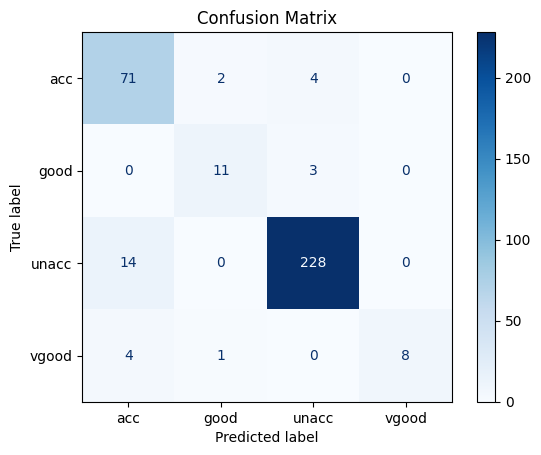

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()